<center> <img src="https://miro.medium.com/v2/resize:fit:1250/format:webp/1*QgI1t-7yJApi4vQigFgsLQ.jpeg" width=25% > </center>

<br><br>

<center> 
    <font size="6">Final Lab (Part 1): Keypoint Detection, Bag of Visual Words and Image Classification</font>
</center>
<center> 
    <font size="4">Computer Vision 1 University of Amsterdam</font> 
</center>
<center> 
    <font size="4">Due 23:59PM, 24th October, 2025 (Amsterdam time)</font> 
</center>

<br><br>

***

<br><br>

<center>

Student1 ID:  \
Student1 Name: 

Student2 ID: \
Student2 Name: 

Student3 ID: \
Student3 Name: 

( Student4 ID: \
Student4 Name: )

</center>

### **General Guidelines**

Your code must be handed in this Jupyter notebook, renamed to **StudentID1_StudentID2_StudentID3.ipynb** before the deadline by submitting it to the Canvas Final Lab (Part 1) Assignment. Please also fill out your names and IDs above.

For full credit, make sure your notebook follows these guidelines:

- Please express your thoughts **concisely**. The number of words does not necessarily correlate with how well you understand the concepts.
- Understand the problem as much as you can. When answering a question, provide evidence (qualitative and/or quantitative results, references to papers, figures, etc.) to support your arguments. Not everything might be explicitly asked for, so think about what might strengthen your arguments to make the notebook self-contained and complete.
- Tables and figures must be accompanied by a **brief** description. Add a number, a title, and, if applicable, the name and unit of variables in a table, and name and unit of axes and legends in a figure.

**Late submissions are not allowed.** Assignments submitted after the strict deadline will not be graded. In case of submission conflicts, TAs’ system clock is taken as reference. We strongly recommend submitting well in advance to avoid last-minute system failure issues.

**Environment:** Since this is a project-based assignment, you are free to use any feature descriptor and machine learning tools (e.g., K-means, SVM). You should use Python for your implementation. You are free to use any Python library for this assignment, but make sure to provide a conda environment file!

**Plagiarism Note:** Keep in mind that plagiarism (submitted materials which are not your work) is a serious offense and any misconduct will be addressed according to university regulations. This includes using generative tools such as ChatGPT.

**Ensure that you save all results/answers to the questions (even if you reuse some code).**

### **Report Preparation**

Your tasks include the following:

1. **Report Preparation:** For both parts of the final project, students are expected to prepare a report. The report should include all details on implementation approaches, analysis of results for different settings, and visualizations illustrating experiments and performance of your implementation. Grading will be based on the report, so it should be as self-contained as possible. If the report contains faulty results or ambiguities, TAs can refer to your code for clarification. Only section 10 of this notebook should **not** be included in the report.

2. **Explanation of Results:** Do not just provide numbers without explanation. Discuss different settings to show your understanding of the material and processes involved.

3. **Quantitative Evaluation:** For quantitative evaluation, you are expected to provide the results based on the mAP (mean Average Precision) metric. You should report the mAP for each experimental setup. 

4. **Qualitative Evaluation:** For qualitative evaluation, you are expected to visualize the top-5 and bottom-5 ranked test images (based on classifier confidence for the target class) per setup. Provide a figure for each experimental setup Visual elements such as charts, graphs, and plots are always useful. Keep this in mind while writing your reports.

5. **Aim:** Understand the basic Image Classification pipeline using a traditional Bag of Visual Words method.

6. **Working on Assignments:** Students should work in assigned groups for **two** weeks. Any questions can be discussed on ED.

    - **Submission:** Submit your source code and report together in a zip file (`ID1_ID2_ID3_part1.zip`). The report should be a maximum of 10 pages (single-column, including tables and figures, excluding references and appendix). Express thoughts concisely. Tables and figures must be accompanied by a description. Number them and, if applicable, name variables in tables, and label axes in figures.

7. **Hyperparameter Search:** In your experiments, remember to perform a hyperparameter search to find the optimal settings for your classifier. Clearly document the search process, the parameters you explored, and how they influenced the performance of your model.

8. **Format and Testing:** The report should be in **PDF format**, and the code in **.ipynb format**. Test that all functionality works as expected in the notebook.

### **Overview**

- [Section 1: Data Preparation (0 points)](#section-1)
- [Section 2: Keypoint Detection and Feature Extraction (3 points)](#section-2)
- [Section 3: Building the Visual Vocabulary (3 points)](#section-3)
- [Section 4: Encoding Train Image Features (3 points)](#section-4)
- [Section 5: Visualizing the Bag of Visual Words for Each Class (3 points)](#section-5)
- [Section 6: Encoding Test Image Features (0 points)](#section-6)
- [Section 7: Training the Classifiers (5 points)](#section-7)
- [Section 8: Evaluating the Classifiers (12 points)](#section-8)
- [Section 9: Hyperparameter Search (16 points)](#section-9)
- [Section 10: Using CLIP for Image Classification (5 points)](#section-10)
- [Section X: Individual Contribution Report (Mandatory)](#section-x)

### **Section 1: Data Preparation (0 points)**

The goal of this lab is to implement an image classification system that can identify objects from a given set of classes. You will perform a 5-class image classification using a bag-of-words approach ([reference](http://www.robots.ox.ac.uk/~az/icvss08_az_bow.pdf)). The classes for this task are:

1. **Frog**
2. **Automobile**
3. **Bird**
4. **Cat**
5. **Deer**

The [CIFAR-10 dataset](https://www.cs.toronto.edu/~kriz/cifar.html) will be used for this task. This dataset contains 32x32 pixel RGB images, divided into sub-directories with 5000 training images and 1000 test images for each class.

The dataset will be automatically downloaded using the code provided in this notebook. You will need to perform training on the training set, which will later be divided into two subsets: one for building the visual vocabulary and another for training the classifier. Using more samples for training generally results in better performance. However, if computational resources are limited, you may use fewer training images to save time, as long as at least 500 images per class are included.

The system must be tested using the specified subset of test images. Use all 1000 test images (per class) to observe the full performance of the model. Ensure that test images are excluded from training to maintain a fair comparison.

In [1]:
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Dataset, Subset
import numpy as np
import matplotlib.pyplot as plt
import cv2

# Define total train and test sizes
total_train_size = 5000  # Default value for total training images
total_test_size = 1000   # Default value for total test images

# Define batch sizes for DataLoader
train_batch_size = total_train_size
test_batch_size = total_test_size

# Define the number of Visual Words
num_of_visual_words = 1000  # Default value for number of visual words

# Number of classes
num_classes = 5

# Compute images per class for training and testing
images_per_class_train = total_train_size // num_classes  # e.g., 5000 // 5 = 1000 per class
images_per_class_test = total_test_size // num_classes    # e.g., 1000 // 5 = 200 per class

# Define the transformations
transform = transforms.Compose([
    transforms.ToTensor(),
    # transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))  
])

# Define the class indices for the 5 selected classes: frog, automobile, bird, cat, and deer
selected_classes = [6, 1, 2, 3, 4]  # 6: frog, 1: automobile, 2: bird, 3: cat, 4: deer
class_to_label = {orig_class: new_label for new_label, orig_class in enumerate(selected_classes)}

# Load the CIFAR-10 training set
train_set = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)

# Function to filter and remap dataset
def filter_dataset(dataset, images_per_class, selected_classes, class_to_label):
    selected_indices = []
    class_counts = {class_idx: 0 for class_idx in selected_classes}
    remapped_labels = []

    for idx, (image, label) in enumerate(dataset):
        if label in selected_classes and class_counts[label] < images_per_class:
            selected_indices.append(idx)
            remapped_labels.append(class_to_label[label])
            class_counts[label] += 1

            # Stop if we have enough samples for each class
            if all(count >= images_per_class for count in class_counts.values()):
                break

    filtered_dataset = Subset(dataset, selected_indices)
    return filtered_dataset, remapped_labels

# Filter and remap training set
filtered_train_set, train_mapped_labels = filter_dataset(train_set, images_per_class_train, selected_classes, class_to_label)

# Load the CIFAR-10 test set
test_set = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

# Filter and remap test set
filtered_test_set, test_mapped_labels = filter_dataset(test_set, images_per_class_test, selected_classes, class_to_label)

# Create data loaders for the filtered datasets
train_data_loader = DataLoader(filtered_train_set, batch_size=train_batch_size, shuffle=False)
test_data_loader = DataLoader(filtered_test_set, batch_size=test_batch_size, shuffle=False)

# Extract all training data and remapped labels
train_images, _ = next(iter(train_data_loader))
train_labels = torch.tensor(train_mapped_labels)

train_images = train_images.permute(0, 2, 3, 1)
print(f"Filtered train data: {train_images.shape}")
print(f"Filtered train labels: {train_labels.shape}")

# Extract all test data and remapped labels
test_images, _ = next(iter(test_data_loader))
test_labels = torch.tensor(test_mapped_labels)

test_images = test_images.permute(0, 2, 3, 1)
print(f"Filtered test data: {test_images.shape}")
print(f"Filtered test labels: {test_labels.shape}")

Files already downloaded and verified
Files already downloaded and verified
Filtered train data: torch.Size([5000, 32, 32, 3])
Filtered train labels: torch.Size([5000])
Filtered test data: torch.Size([1000, 32, 32, 3])
Filtered test labels: torch.Size([1000])


<a id="section-2"></a>
### **Section 2: Keypoint Detection and Feature Extraction (3 points)**

In this section, you will work on detecting keypoints and extracting features from the dataset. Your task is to use **two different feature extraction techniques** to identify keypoints in the images. Visualize two images from each of the five classes (Frog, Automobile, Bird, Cat, Deer) for both feature extraction techniques. For each image, draw circles around the detected keypoints that represent their size.

This step is essential to understand how different feature extractors behave across various classes, setting the foundation for further analysis and classification in later steps.

**Hint:** You can use the OpenCV library to detect keypoints and extract features. You can also upscale the images to improve the visualization of the keypoints.

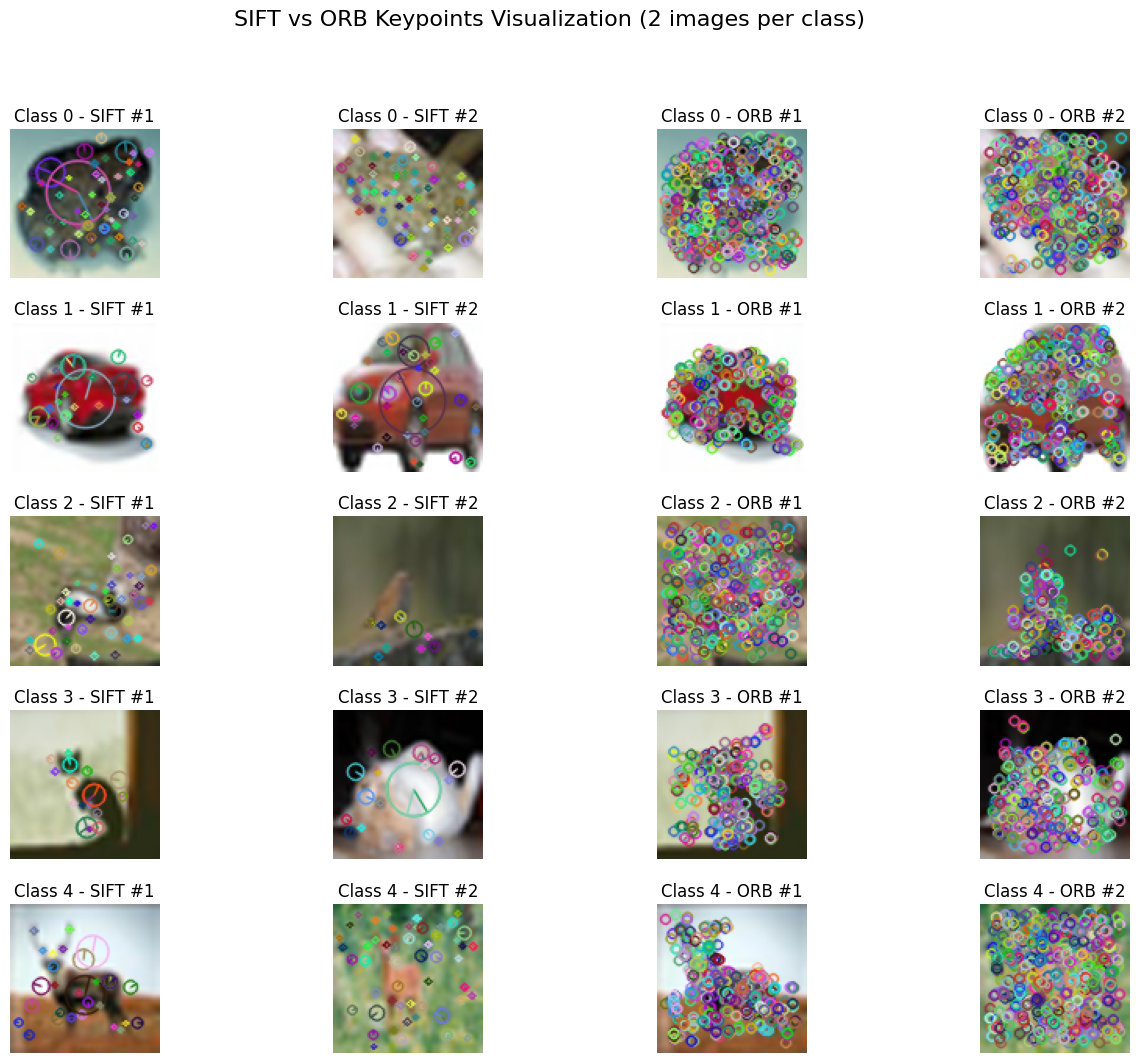


--- LaTeX Table Code ---

\begin{table}[h!]
\centering
\begin{tabular}{c c c c}
\hline
Class & SIFT Sample 1 & SIFT Sample 2 & ORB Sample 1 & ORB Sample 2 \\
\hline
0 & \includegraphics[width=0.18\textwidth]{keypoint_images/class0_sift_1.png} & \includegraphics[width=0.18\textwidth]{keypoint_images/class0_sift_2.png} & \includegraphics[width=0.18\textwidth]{keypoint_images/class0_orb_1.png} & \includegraphics[width=0.18\textwidth]{keypoint_images/class0_orb_2.png} \\
1 & \includegraphics[width=0.18\textwidth]{keypoint_images/class1_sift_1.png} & \includegraphics[width=0.18\textwidth]{keypoint_images/class1_sift_2.png} & \includegraphics[width=0.18\textwidth]{keypoint_images/class1_orb_1.png} & \includegraphics[width=0.18\textwidth]{keypoint_images/class1_orb_2.png} \\
2 & \includegraphics[width=0.18\textwidth]{keypoint_images/class2_sift_1.png} & \includegraphics[width=0.18\textwidth]{keypoint_images/class2_sift_2.png} & \includegraphics[width=0.18\textwidth]{keypoint_images/class2_or

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import random
import torch
import os
import shutil

# --- CONFIG ---
output_dir = "keypoint_images"
resize_size = (96, 96)
num_samples_per_class = 2
num_classes_to_show = 5

# --- CLEAR AND CREATE OUTPUT FOLDER ---
if os.path.exists(output_dir):
    shutil.rmtree(output_dir)
os.makedirs(output_dir, exist_ok=True)

# --- CONVERT TENSORS TO NUMPY ---
images_np = train_images.numpy() if isinstance(train_images, torch.Tensor) else train_images
labels_np = train_labels.numpy() if isinstance(train_labels, torch.Tensor) else train_labels

# Ensure uint8 type and 0-255 range
if images_np.max() <= 1.0:
    images_np = (images_np * 255).astype(np.uint8)

# --- INITIALIZE FEATURE DETECTORS ---
sift = cv2.SIFT_create()
orb = cv2.ORB_create(nfeatures=1000, edgeThreshold=5, fastThreshold=5)

# --- SELECT CLASSES ---
classes_to_show = np.unique(labels_np)[:num_classes_to_show]  # first 5 classes

# --- VISUALIZATION AND SAVING ---
fig, axes = plt.subplots(len(classes_to_show), 4, figsize=(16, 12))
plt.subplots_adjust(hspace=0.3, wspace=0.2)

# Keep track of saved filenames for LaTeX table
saved_filenames = []

for i, cls in enumerate(classes_to_show):
    # Pick random images from this class
    idxs = np.where(labels_np == cls)[0]
    selected_idxs = random.sample(list(idxs), num_samples_per_class)

    for j, idx in enumerate(selected_idxs):
        img = images_np[idx]
        img_resized = cv2.resize(img, resize_size, interpolation=cv2.INTER_CUBIC)
        img_gray = cv2.cvtColor(img_resized, cv2.COLOR_RGB2GRAY)

        # --- SIFT ---
        keypoints_sift, _ = sift.detectAndCompute(img_gray, None)
        img_sift = cv2.drawKeypoints(img_resized, keypoints_sift, None,
                                     flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
        fname_sift = f"{output_dir}/class{cls}_sift_{j+1}.png"
        cv2.imwrite(fname_sift, cv2.cvtColor(img_sift, cv2.COLOR_RGB2BGR))
        saved_filenames.append(("SIFT", cls, fname_sift))

        # --- ORB ---
        keypoints_orb, _ = orb.detectAndCompute(img_gray, None)
        img_orb = cv2.drawKeypoints(img_resized, keypoints_orb, None,
                                    flags=cv2.DRAW_MATCHES_FLAGS_DEFAULT)
        fname_orb = f"{output_dir}/class{cls}_orb_{j+1}.png"
        cv2.imwrite(fname_orb, cv2.cvtColor(img_orb, cv2.COLOR_RGB2BGR))
        saved_filenames.append(("ORB", cls, fname_orb))

        # --- PLOT FOR QUICK VISUAL CHECK ---
        axes[i, j].imshow(img_sift)
        axes[i, j].set_title(f"Class {cls} - SIFT #{j+1}")
        axes[i, j].axis('off')

        axes[i, j + 2].imshow(img_orb)
        axes[i, j + 2].set_title(f"Class {cls} - ORB #{j+1}")
        axes[i, j + 2].axis('off')

plt.suptitle("SIFT vs ORB Keypoints Visualization (2 images per class)", fontsize=16)
plt.show()

# --- PRINT LATEX TABLE ---
print("\n--- LaTeX Table Code ---\n")
print("\\begin{table}[h!]")
print("\\centering")
print("\\begin{tabular}{c c c c}")
print("\\hline")
print("Class & SIFT Sample 1 & SIFT Sample 2 & ORB Sample 1 & ORB Sample 2 \\\\")
print("\\hline")

for cls in classes_to_show:
    sift_imgs = [fname for typ, c, fname in saved_filenames if typ == "SIFT" and c == cls]
    orb_imgs  = [fname for typ, c, fname in saved_filenames if typ == "ORB" and c == cls]
    row = f"{cls} & "
    row += " & ".join([f"\\includegraphics[width=0.18\\textwidth]{{{img}}}" for img in sift_imgs])
    row += " & "
    row += " & ".join([f"\\includegraphics[width=0.18\\textwidth]{{{img}}}" for img in orb_imgs])
    row += " \\\\"
    print(row)

print("\\hline")
print("\\end{tabular}")
print("\\caption{SIFT vs ORB keypoints for sample images.}")
print("\\end{table}")


<a id="section-3"></a>
### **Section 3: Building the Visual Vocabulary (3 points)**

In this section, the task is to create a visual vocabulary by clustering feature descriptors extracted from the images using K-Means. Each cluster center in this vocabulary will represent a visual word. Use the two different extraction techniques you implemented to extract descriptors from a subset of training images that includes all categories, and then apply K-Means clustering to build the vocabulary. The number of clusters is fixed at 1000, but you can experiment with different values when you are tuning the hyperparameters in section 9.

To examine the effect of different amounts of training data, build separate visual vocabularies using 30%, 40%, and 50% subsets of the training images. For faster clustering, the `faiss` library can be used, as it provides an efficient implementation of K-Means. Then, visualize the first 10 clusters for each feature extraction technique and each subset size using PCA to reduce the dimensions to 2D.

**Hints:**
1. Begin by debugging the code with a small number of input images to ensure it functions correctly before running it on larger datasets.
2. If the `faiss` library is not available, K-Means clustering can also be performed using the `sklearn` or `scipy` libraries.
3. For visualization, use PCA from `sklearn.decomposition` to reduce the high-dimensional descriptors to 2D. Display up to 10 clusters in the scatter plot to maintain clarity.


===== Building Visual Vocabulary (30% subset) =====


Extracting SIFT descriptors: 100%|██████████| 1500/1500 [00:03<00:00, 491.89it/s]


→ Extracted 73221 total descriptors with dim 128 (SIFT)
[[ 18.   1.   1. ...   0.   0.   0.]
 [  0.   0.   4. ...   0.   0.   0.]
 [  1.  23. 113. ...  16.   2.   2.]
 ...
 [ 10.  36.  22. ...   0.   0.   0.]
 [ 15.   1.   0. ...   0.   0.   0.]
 [  3.   1.   1. ...   0.   0.   0.]]
Initialization complete
Iteration 0, inertia 7623995392.0.
Iteration 1, inertia 5560418304.0.
Iteration 2, inertia 5446538752.0.
Iteration 3, inertia 5399555072.0.
Iteration 4, inertia 5372654592.0.
Iteration 5, inertia 5355495424.0.
Iteration 6, inertia 5343177216.0.
Iteration 7, inertia 5333772800.0.
Iteration 8, inertia 5326369280.0.
Iteration 9, inertia 5320633856.0.
Iteration 10, inertia 5315615232.0.
Iteration 11, inertia 5311667712.0.
Iteration 12, inertia 5308203008.0.
Iteration 13, inertia 5305321984.0.
Iteration 14, inertia 5302964736.0.
Iteration 15, inertia 5301051904.0.
Iteration 16, inertia 5299456000.0.
Iteration 17, inertia 5298149888.0.
Iteration 18, inertia 5297014784.0.
Iteration 19, iner

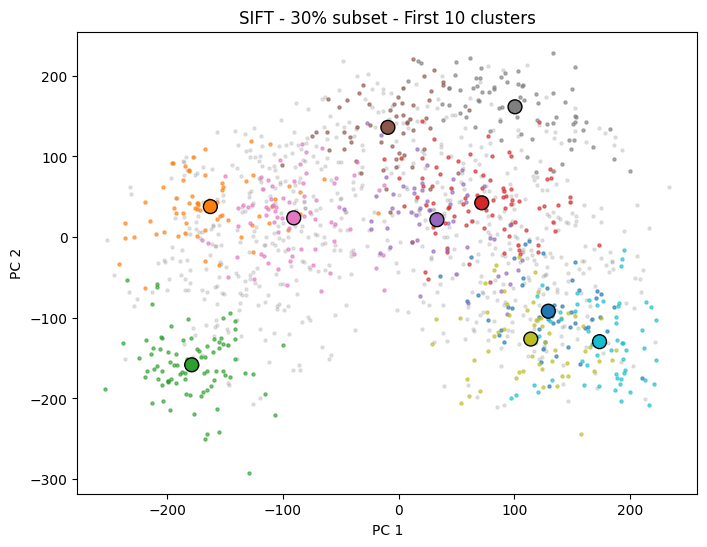

Extracting ORB descriptors: 100%|██████████| 1500/1500 [00:00<00:00, 2568.10it/s]


→ Extracted 17369 total descriptors with dim 32 (ORB)
[[ 84 204 239 ... 249 181 224]
 [ 85 169 245 ... 227   3 113]
 [245 237 197 ... 251 210  32]
 ...
 [120 177 168 ...  76 214 114]
 [ 66 185 147 ...   6 135 127]
 [187 207  98 ... 158 248 221]]
Initialization complete
Iteration 0, inertia 1682637166.0.
Iteration 1, inertia 1323827284.940701.
Iteration 2, inertia 1284893872.18108.
Iteration 3, inertia 1270076918.9969437.
Iteration 4, inertia 1262816381.54864.
Iteration 5, inertia 1258530173.5767503.
Iteration 6, inertia 1256036526.0066261.
Iteration 7, inertia 1254451514.6312602.
Iteration 8, inertia 1253427561.2686007.
Iteration 9, inertia 1252761148.6010725.
Iteration 10, inertia 1252308590.4065337.
Iteration 11, inertia 1252026861.468008.
Iteration 12, inertia 1251854652.445662.
Iteration 13, inertia 1251716702.0767164.
Iteration 14, inertia 1251607243.6865263.
Iteration 15, inertia 1251491686.7116113.
Iteration 16, inertia 1251420341.072217.
Iteration 17, inertia 1251366606.8809233

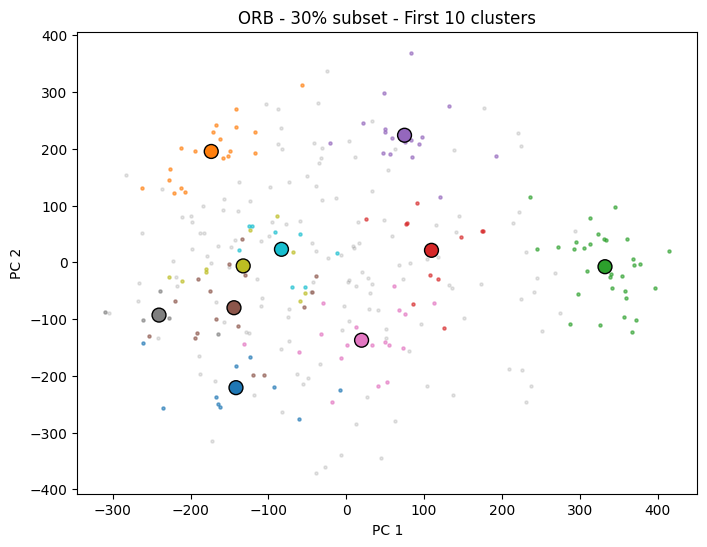


===== Building Visual Vocabulary (40% subset) =====


Extracting SIFT descriptors: 100%|██████████| 2000/2000 [00:03<00:00, 558.55it/s]


→ Extracted 96476 total descriptors with dim 128 (SIFT)
[[  1.  16.  21. ...   0.   1.   4.]
 [  0.   7.  85. ...   0.   0.   1.]
 [  1.   1.  17. ...   7.   0.   0.]
 ...
 [ 25.   3.   1. ...  66.   5.   0.]
 [ 10.   6.   5. ...   2.   2.   1.]
 [ 36. 129.  14. ...   0.   0.   0.]]
Initialization complete
Iteration 0, inertia 10051378176.0.
Iteration 1, inertia 7343130624.0.
Iteration 2, inertia 7198458368.0.
Iteration 3, inertia 7137204224.0.
Iteration 4, inertia 7101461504.0.
Iteration 5, inertia 7077507584.0.
Iteration 6, inertia 7060683776.0.
Iteration 7, inertia 7048576000.0.
Iteration 8, inertia 7039484928.0.
Iteration 9, inertia 7032412160.0.
Iteration 10, inertia 7026827264.0.
Iteration 11, inertia 7022352384.0.
Iteration 12, inertia 7018355200.0.
Iteration 13, inertia 7014942720.0.
Iteration 14, inertia 7011820544.0.
Iteration 15, inertia 7009076224.0.
Iteration 16, inertia 7006717440.0.
Iteration 17, inertia 7004533760.0.
Iteration 18, inertia 7002583552.0.
Iteration 19, ine

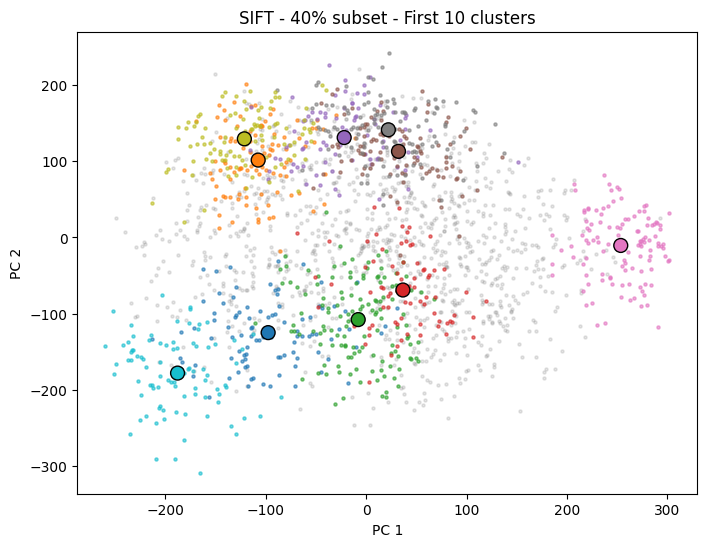

Extracting ORB descriptors: 100%|██████████| 2000/2000 [00:00<00:00, 2930.53it/s]


→ Extracted 23766 total descriptors with dim 32 (ORB)
[[ 26 126 114 ...  85  45 223]
 [138  98  26 ... 176  39 129]
 [167 232 161 ...  29  91 220]
 ...
 [ 66 184 127 ...   0  37 250]
 [  2  50 238 ... 140  61 215]
 [ 65  29  23 ... 114  41  62]]
Initialization complete
Iteration 0, inertia 2333079662.0.
Iteration 1, inertia 1856957961.6786451.
Iteration 2, inertia 1802182651.4188643.
Iteration 3, inertia 1780789217.198577.
Iteration 4, inertia 1769644777.179244.
Iteration 5, inertia 1762665287.0000577.
Iteration 6, inertia 1758363099.3744354.
Iteration 7, inertia 1755766554.4508705.
Iteration 8, inertia 1753968693.6695156.
Iteration 9, inertia 1752754581.679154.
Iteration 10, inertia 1751891889.6759176.
Iteration 11, inertia 1751328984.9114397.
Iteration 12, inertia 1750992733.5890794.
Iteration 13, inertia 1750703015.0061848.
Iteration 14, inertia 1750472250.7981348.
Iteration 15, inertia 1750318797.1234217.
Iteration 16, inertia 1750252165.9576278.
Iteration 17, inertia 1750196938.39

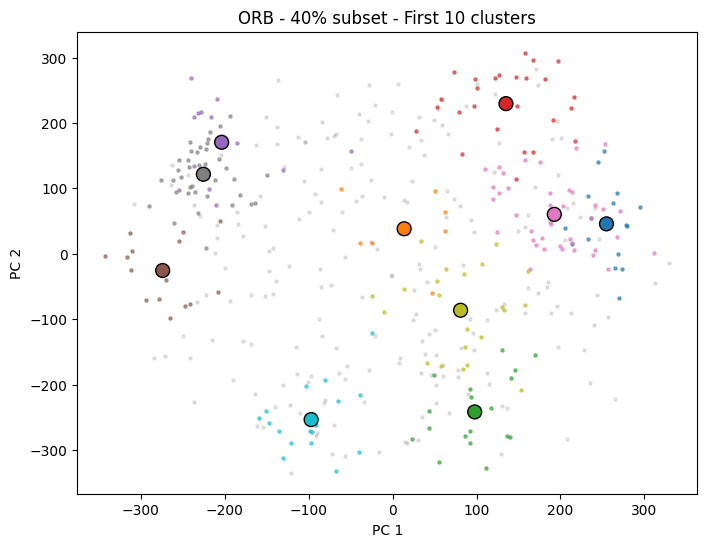


===== Building Visual Vocabulary (50% subset) =====


Extracting SIFT descriptors: 100%|██████████| 2500/2500 [00:04<00:00, 546.40it/s]


→ Extracted 122862 total descriptors with dim 128 (SIFT)
[[ 35.  70.   2. ...  33. 124.   8.]
 [ 12.  58.  72. ...   0.   0.   0.]
 [  0.   0.   0. ... 113.  40.  89.]
 ...
 [  5.  11.  26. ...  84. 120.   0.]
 [  5.  89. 120. ...  10.  25.  30.]
 [ 26.  47.  12. ...   1.  40.  64.]]
Initialization complete
Iteration 0, inertia 12846194688.0.
Iteration 1, inertia 9389174784.0.
Iteration 2, inertia 9209892864.0.
Iteration 3, inertia 9133665280.0.
Iteration 4, inertia 9088584704.0.
Iteration 5, inertia 9058907136.0.
Iteration 6, inertia 9037210624.0.
Iteration 7, inertia 9021016064.0.
Iteration 8, inertia 9008399360.0.
Iteration 9, inertia 8998512640.0.
Iteration 10, inertia 8990380032.0.
Iteration 11, inertia 8983363584.0.
Iteration 12, inertia 8977403904.0.
Iteration 13, inertia 8972398592.0.
Iteration 14, inertia 8968054784.0.
Iteration 15, inertia 8964258816.0.
Iteration 16, inertia 8961060864.0.
Iteration 17, inertia 8958140416.0.
Iteration 18, inertia 8955504640.0.
Iteration 19, in

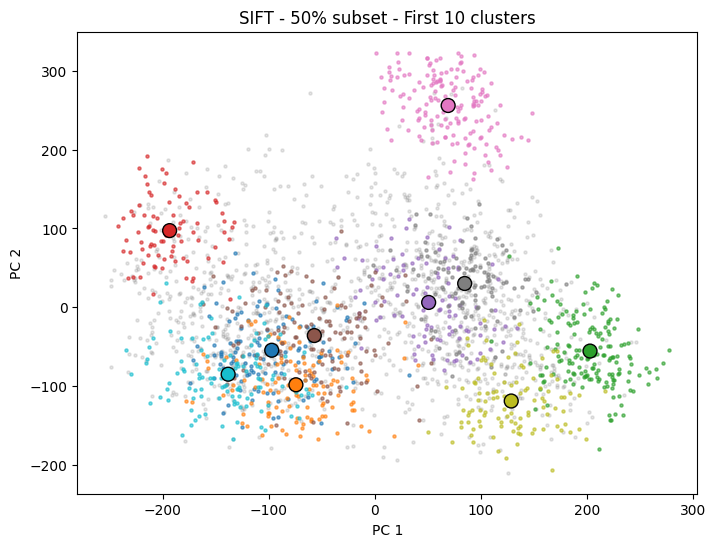

Extracting ORB descriptors: 100%|██████████| 2500/2500 [00:01<00:00, 2305.87it/s]


→ Extracted 29316 total descriptors with dim 32 (ORB)
[[191 255 226 ... 255 124 223]
 [174 246 248 ... 247 175 211]
 [222 127 246 ... 255 165  87]
 ...
 [157  72  95 ... 179 105  33]
 [157 221  23 ... 253 161  60]
 [ 92 249 145 ... 179  10  33]]
Initialization complete
Iteration 0, inertia 2916731181.0.
Iteration 1, inertia 2334017868.329565.
Iteration 2, inertia 2269050868.222225.
Iteration 3, inertia 2242727430.126533.
Iteration 4, inertia 2228258474.012658.
Iteration 5, inertia 2219506479.429446.
Iteration 6, inertia 2213512213.3455014.
Iteration 7, inertia 2209414581.031638.
Iteration 8, inertia 2206716675.3406096.
Iteration 9, inertia 2204712497.497729.
Iteration 10, inertia 2203284347.753455.
Iteration 11, inertia 2202071520.596593.
Iteration 12, inertia 2201197006.398797.
Iteration 13, inertia 2200389724.4242578.
Iteration 14, inertia 2199794548.080518.
Iteration 15, inertia 2199431813.5642233.
Iteration 16, inertia 2199220842.274848.
Iteration 17, inertia 2199096062.5066385.
It

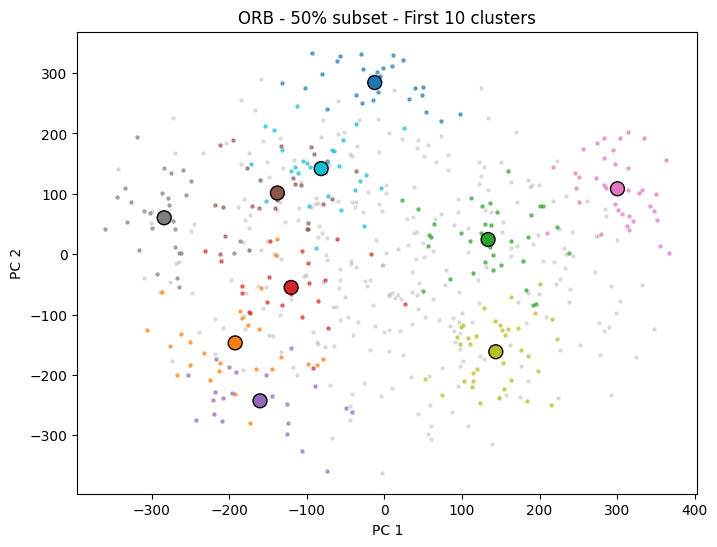

In [14]:
# YOUR CODE HERE

import numpy as np
import random
import cv2
from tqdm import tqdm
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# ============================================================
# Helper Functions
# ============================================================

def extract_descriptors(images, feature_type="SIFT", max_images=None, upscale_size=(96, 96)):
    """
    Extract descriptors for a subset of images using SIFT or ORB.
    Returns a concatenated descriptor array (N_descriptors, dim)
    """
    if feature_type == "SIFT":
        extractor = cv2.SIFT_create()
    elif feature_type == "ORB":
        extractor = cv2.ORB_create(nfeatures=500)  # Increase keypoints for small images
    else:
        raise ValueError("feature_type must be 'SIFT' or 'ORB'.")

    descriptors_list = []
    selected_idxs = np.arange(len(images)) if max_images is None else np.random.choice(len(images), max_images, replace=False)

    for idx in tqdm(selected_idxs, desc=f"Extracting {feature_type} descriptors"):
        img = images[idx]
        img_up = cv2.resize(img, upscale_size, interpolation=cv2.INTER_CUBIC)
        gray = cv2.cvtColor(img_up, cv2.COLOR_RGB2GRAY)
        _, desc = extractor.detectAndCompute(gray, None)
        if desc is not None and len(desc) > 0:
            descriptors_list.append(desc)

    if len(descriptors_list) == 0:
        raise ValueError(f"No descriptors found for {feature_type}. Try using more images or a different feature extractor.")

    # Concatenate all descriptors
    all_desc = np.vstack(descriptors_list)
    print(f"→ Extracted {all_desc.shape[0]} total descriptors with dim {all_desc.shape[1]} ({feature_type})")
    print(all_desc)
    return all_desc, selected_idxs



def build_vocabulary(descriptors, n_clusters=1000):
    """
    Cluster descriptors into visual words using K-Means (sklearn)
    """
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, verbose=1)
    kmeans.fit(descriptors)
    centers = kmeans.cluster_centers_
    labels = kmeans.labels_
    return centers, labels


def visualize_clusters(descriptors, centers, labels, n_show=10, feature_type="SIFT", subset_ratio=None):
    """
    Visualize cluster centers in 2D using PCA.
    Show first n_show clusters with some background descriptors.
    """
    # Mask for first n_show clusters
    mask_show = labels < n_show
    descriptors_show = descriptors[mask_show]
    labels_show = labels[mask_show]

    # Count how many points to sample from other clusters
    n_background = len(descriptors_show)

    # Mask for other clusters
    mask_bg = labels >= n_show
    descriptors_bg = descriptors[mask_bg]
    if len(descriptors_bg) > n_background:
        idxs_bg = np.random.choice(len(descriptors_bg), n_background, replace=False)
        descriptors_bg = descriptors_bg[idxs_bg]

    # Combine for PCA
    descriptors_plot = np.vstack([descriptors_show, descriptors_bg])

    # Reduce to 2D
    pca = PCA(n_components=2)
    reduced_desc = pca.fit_transform(descriptors_plot)
    reduced_centers = pca.transform(centers[:n_show])

    # Split back
    reduced_show = reduced_desc[:len(descriptors_show)]
    reduced_bg = reduced_desc[len(descriptors_show):]

    plt.figure(figsize=(8,6))

    # Plot background descriptors
    plt.scatter(reduced_bg[:, 0], reduced_bg[:, 1], s=5, alpha=0.2, c='gray', label='Other clusters')

    # Plot first n_show clusters
    colors = ['C'+str(i) for i in range(n_show)]
    for i in range(n_show):
        cluster_points = reduced_show[labels_show == i]
        plt.scatter(cluster_points[:, 0], cluster_points[:, 1], s=5, alpha=0.6, c=colors[i], label=f"Cluster {i}")

    # Plot cluster centers
    plt.scatter(reduced_centers[:, 0], reduced_centers[:, 1],
                c=colors[:n_show], s=100, edgecolor='black', label="Cluster centers")

    plt.title(f"{feature_type} - {subset_ratio*100:.0f}% subset - First {n_show} clusters")
    plt.xlabel("PC 1")
    plt.ylabel("PC 2")
    # plt.legend()
    plt.savefig(f"{feature_type}_vocabulary_{int(subset_ratio*100)}pct.png", dpi=100)
    plt.show()




# ============================================================
# Main Section
# ============================================================

# Assume train_images and train_labels available from previous section
images_np = train_images.numpy() if isinstance(train_images, torch.Tensor) else train_images
if images_np.max() <= 1.0:
    images_np = (images_np * 255).astype(np.uint8)

subset_ratios = [0.3, 0.4, 0.5]
n_clusters = 1000

for ratio in subset_ratios:
    n_imgs = int(len(images_np) * ratio)
    print(f"\n===== Building Visual Vocabulary ({int(ratio*100)}% subset) =====")

    # SIFT
    sift_desc, sift_idxs = extract_descriptors(images_np, feature_type="SIFT", max_images=n_imgs)
    sift_centers, sift_labels = build_vocabulary(sift_desc, n_clusters=n_clusters)
    visualize_clusters(sift_desc, sift_centers, sift_labels, n_show=10, feature_type="SIFT", subset_ratio=ratio)

    # ORB
    orb_desc, orb_idxs = extract_descriptors(images_np, feature_type="ORB", max_images=n_imgs)
    orb_centers, orb_labels = build_vocabulary(orb_desc, n_clusters=n_clusters)
    visualize_clusters(orb_desc, orb_centers, orb_labels, n_show=10, feature_type="ORB", subset_ratio=ratio)


<a id="section-4"></a>
### **Section 4: Encoding Train Image Features (3 points)**

In this section, the task is to encode image features using the visual vocabulary created earlier. Each image will be represented as a histogram of visual words, reflecting the frequency of each visual word in the image. This representation will allow for comparing images based on their visual content.

To encode an image, identify the nearest visual word (cluster center) for each feature descriptor extracted from the image. Construct a histogram that counts the occurrences of each visual word within the image. The final output will be a collection of histograms, one for each image, where each histogram serves as the feature representation of that image. Once again,  Use the two different extraction techniques you implemented to extract descriptors from the images. Then, encode the images using the visual vocabulary created in the previous step.

**Hint:** Utilize the `faiss` library for efficient nearest neighbor search when assigning each descriptor to the nearest cluster center in the visual dictionary. If `faiss` is not available, consider using other libraries, such as `scikit-learn`, for this step. Once the histograms are obtained, they will be used for further tasks, such as training a classifier. For now, perform the encoding only for the training set.

In [ ]:
# YOUR CODE HERE
import numpy as np
import cv2
from tqdm import tqdm

# ============================================================
# Helper Functions
# ============================================================

def extract_image_descriptors(img, feature_type="SIFT"):
    """Extract descriptors from a single image."""
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    if feature_type == "SIFT":
        extractor = cv2.SIFT_create()
    elif feature_type == "ORB":
        extractor = cv2.ORB_create(nfeatures=500, edgeThreshold = 6)
    else:
        raise ValueError("feature_type must be 'SIFT' or 'ORB'.")
    
    _, desc = extractor.detectAndCompute(gray, None)
    return desc  # may be None


def encode_image(descriptors, vocab):
    """
    Encode a single image into a histogram of visual words.
    descriptors: (N_descriptors, dim)
    vocab: (n_clusters, dim)
    returns: histogram (n_clusters,)
    """
    n_clusters = vocab.shape[0]
    if descriptors is None:
        return np.zeros(n_clusters, dtype=np.float32)
    
    from sklearn.neighbors import NearestNeighbors
    nbrs = NearestNeighbors(n_neighbors=1, algorithm='auto').fit(vocab)
    nn_idx = nbrs.kneighbors(descriptors, return_distance=False).flatten()

    # Build histogram
    hist = np.bincount(nn_idx, minlength=n_clusters).astype(np.float32)
    hist = hist / np.sum(hist)  # normalize histogram
    return hist


def encode_dataset(images, vocab, feature_type="SIFT"):
    """
    Encode an entire dataset of images into BoVW histograms.
    returns: histograms (N_images, n_clusters)
    """
    all_hist = []
    for img in tqdm(images, desc=f"Encoding images with {feature_type}"):
        desc = extract_image_descriptors(img, feature_type=feature_type)
        hist = encode_image(desc, vocab)
        all_hist.append(hist)
    return np.array(all_hist, dtype=np.float32)

# images_np: (N_images, H, W, 3)

# Encode SIFT histograms
sift_histograms = encode_dataset(images_np, sift_centers, feature_type="SIFT")
print("SIFT BoVW histograms shape:", sift_histograms.shape)

# Encode ORB histograms
orb_histograms = encode_dataset(images_np, orb_centers, feature_type="ORB")
print("ORB BoVW histograms shape:", orb_histograms.shape)


<a id="section-5"></a>
### **Section 5: Visualizing the Bag of Visual Words for Each Class (3 points)**

In this section, the task is to visualize the Bag of Visual Words for each class using the histograms generated in the previous step. The goal is to plot the mean histogram of visual words for each class, showing the distribution of visual words across the different categories in the training set.

Use the two different extraction techniques you implemented for this visualization. For each technique, calculate the mean histogram for each class and create a bar plot to display these histograms. Ensure that the plots are labeled clearly with the class names and feature descriptor types.

In [ ]:
def plot_mean_histograms(histograms, labels, class_names, feature_type):
    n_classes = len(class_names)
    n_clusters = histograms.shape[1]

    plt.figure(figsize=(12, 6))
    for i, class_name in enumerate(class_names):
        class_hist = histograms[np.array(labels) == i]
        if len(class_hist) == 0:
            continue

        mean_hist = np.mean(class_hist, axis=0)
        plt.bar(np.arange(n_clusters) + i * (0.8 / n_classes),
                mean_hist,
                width=(0.8 / n_classes),
                label=class_name)

    plt.title(f"Mean BoVW Histogram per Class ({feature_type})")
    plt.xlabel("Visual Word Index")
    plt.ylabel("Normalized Frequency")
    plt.legend()
    plt.tight_layout()
    plt.show()

class_names = ["frog", "automobile", "bird", "cat", "deer"]

# Plot for train set
plot_mean_histograms(sift_histograms, train_mapped_labels, class_names, feature_type="SIFT")
plot_mean_histograms(orb_histograms, train_mapped_labels, class_names, feature_type="ORB")

<a id="section-6"></a>
### **Section 6: Encoding Test Image Features (0 points)**

In this section, the task is to encode the test image features using the visual vocabulary created from the training set. Similar to the previous encoding step, each test image will be represented as a histogram of visual words, which will then be used for evaluating classification performance.

Use the same two feature extraction techniques you selected earlier. Extract keypoints and descriptors for the test images, then encode these images using the visual vocabulary. This will allow you to compare the encoded features of test images against those of the training set.

**Hint:** Reuse the functions developed earlier for extracting keypoints, descriptors, and encoding images. Ensure that you use the visual vocabulary constructed with the training images for consistency.

In [ ]:
test_images_np = test_images.numpy() if isinstance(test_images, torch.Tensor) else test_images
if test_images_np.max() <= 1.0:
    test_images_np = (test_images_np * 255).astype(np.uint8)

# Encode SIFT histograms for test images
test_sift_histograms = encode_dataset(test_images_np, sift_centers, feature_type="SIFT")
print("Test SIFT histograms shape:", test_sift_histograms.shape)

# Encode ORB histograms for test images
test_orb_histograms = encode_dataset(test_images_np, orb_centers, feature_type="ORB")
print("Test ORB histograms shape:", test_orb_histograms.shape)

<a id="section-7"></a>
### **Section 7: Training the Classifiers (5 points)**

In this section, the task is to create two one-vs-rest (OvR) SVM classifiers using the 50% of the training data that was **not** used for creating the visual dictionary. This ensures that the classifiers are trained on a different subset of data, providing a more robust evaluation of the visual vocabulary's effectiveness.

For each of the two selected feature extraction techniques, create one-vs-rest classifiers for all classes. For now, use default parameter values when training the classifiers; you will experiment with different hyperparameters in later steps.

**Note:** Training an OvR classifier can take around 5 to 7 minutes. Therefore, it's advisable to first test your code with a smaller subset of the training data to verify that your implementation works correctly before running it on the full dataset.

In [ ]:
from sklearn.svm import SVC
from sklearn.multiclass import OneVsRestClassifier  

all_indices = np.arange(len(labels_np))

# --- SIFT ---
train_svm_indices_sift = np.setdiff1d(all_indices, sift_idxs)  # complement of vocab images
X_train_sift = sift_histograms[train_svm_indices_sift]
y_train_sift = labels_np[train_svm_indices_sift]

svm_sift = OneVsRestClassifier(SVC(kernel='linear', random_state=42))
svm_sift.fit(X_train_sift, y_train_sift)

# --- ORB ---
train_svm_indices_orb = np.setdiff1d(all_indices, orb_idxs)  # complement of vocab images
X_train_orb = orb_histograms[train_svm_indices_orb]
y_train_orb = labels_np[train_svm_indices_orb]

svm_orb = OneVsRestClassifier(SVC(kernel='linear', random_state=42))
svm_orb.fit(X_train_orb, y_train_orb)

<a id="section-8"></a>
### **Section 8: Evaluating the Classifiers (12 points)**

In this section, you will evaluate the performance of your one-vs-rest (OvR) SVM classifiers on the test data. The goal is to classify each test image using each binary classifier and rank the images based on the classification scores, resulting in a ranked list of images for each class. Ideally, images belonging to the target class should appear at the top of the respective list. To conduct this evaluation, use the test image histograms generated earlier for the two selected feature extraction techniques. Classify each test image with each classifier, rank them based on their confidence scores, and then compute the Mean Average Precision (mAP) across all classes. The mAP for a single class $c$ is defined as:

$
\text{mAP}_c = \frac{1}{m_c} \sum_{i=1}^{n} \frac{f_c(x_i)}{i}
$

where:
- $n$ is the total number of images ($n = 50 \times 5 = 250$),
- $m_c$ is the number of images of class $c$ ($m_c = 50$),
- $x_i$ is the $i^{th}$ image in the ranked list $X = \{ x_1, x_2, \dots, x_n \}$,
- $f_c$ is a function that returns the number of images of class $c$ in the first $i$ images if $x_i$ is of class $c$, and 0 otherwise.

For instance, if you are retrieving images of class "R" and the sequence of ranked images is $[R, R, T, R, T, T, R, T]$, then $n = 8$, $m_c = 4$, and:

$
AP = \frac{1}{4} \left( \frac{1}{1} + \frac{2}{2} + \frac{0}{3} + \frac{3}{4} + \frac{0}{5} + \frac{0}{6} + \frac{4}{7} + \frac{0}{8} \right).
$

In addition to the quantitative analysis, perform a qualitative analysis by visualizing the top-5 and bottom-5 ranked test images.

In [ ]:
def evaluate_classifiers(classifier, test_hist, ovr_classifier, images, labels, class_names=None, top_k=5):
    """
    Evaluate OvR SVM classifiers using mAP and visualize top/bottom ranked images.
    
    Parameters:
    - test_hist: (N_test, n_features) BoVW histograms
    - classifiers: list of trained SVM classifiers, one per class
    - images: array of test images
    - labels: class labels
    - class_names: list of class names
    - top_k: number of images to show at top/bottom
    """
    classifiers = ovr_classifier.estimators_
    n_classes = 5

    # compute scores
    scores = ovr_classifier.decision_function(test_hist)

    # rank images for each class
    ranked_indices = [np.argsort(-scores[:, i]) for i in range(n_classes)]

    # compute mAP
    def compute_ap(ranked_idx, true_labels, target_class):
        m_c = np.sum(true_labels == target_class)
        if m_c == 0:
            return 0.0
        count = 0
        ap_sum = 0
        for rank, idx in enumerate(ranked_idx, 1):
            if true_labels[idx] == target_class:
                count += 1
                ap_sum += count / rank
        return ap_sum / m_c

    maps = [compute_ap(ranked_indices[i], labels, i) for i in range(n_classes)]
    mean_ap = np.mean(maps)
    print("mAP per class:", maps)
    print("Mean mAP:", mean_ap)

    # visualize top/bottom images
    print(f"{classifier} Ranking")
    for i in range(n_classes):
        name = class_names[i] if class_names else str(i)
        idxs = ranked_indices[i]

        # top-k
        plt.figure(figsize=(12,3))
        for j in range(top_k):
            plt.subplot(1, top_k, j+1)
            plt.imshow(images[idxs[j]])
            plt.axis('off')
            plt.title(f"Rank {j+1}")
        plt.suptitle(f"{name} - Top {top_k} - {classifier}")
        plt.show()

        # bottom-k
        plt.figure(figsize=(12,3))
        for j in range(1, top_k+1):
            plt.subplot(1, top_k, j)
            plt.imshow(images[idxs[-j]])
            plt.axis('off')
            plt.title(f"Rank {-j}")
        plt.suptitle(f"{name} - Bottom {top_k} - {classifier}")
        plt.show()

    return maps, mean_ap, ranked_indices

# Example for SIFT
maps_sift, mean_ap_sift, ranked_sift = evaluate_classifiers(
    classifier="SIFT",
    test_hist=test_sift_histograms,
    ovr_classifier=svm_sift,
    images=test_images_np,
    labels=test_labels.numpy(),
    class_names = ["frog", "automobile", "bird", "cat", "deer"],
    top_k=5
)

# Example for ORB
maps_orb, mean_ap_orb, ranked_orb = evaluate_classifiers(
    classifier="ORB",
    test_hist=test_orb_histograms,
    ovr_classifier=svm_orb,
    images=test_images_np,
    labels=test_labels.numpy(),
    class_names = ["frog", "automobile", "bird", "cat", "deer"],
    top_k=5
)

<a id="section-9"></a>
### **Section 9: Hyperparameter Search (16 points)**

In this section, the task is to perform an extensive hyperparameter search to optimize the performance of your classifiers. You will experiment with various parameters, including the number of visual words (e.g., 500, 1000, 1500), different training subset sizes (e.g., 30%, 40%, 50%), SVM parameters (e.g., kernel types like 'linear' or 'rbf', regularization parameter $C$ values such as 0.1, 1, 10, and gamma settings like 'scale' or specific values such as 0.01, 0.001), and settings of the feature extractors (e.g., the number of keypoints or scale levels). Start by testing your code on the smallest subset to ensure it functions correctly before proceeding with a full hyperparameter search. Once validated, conduct the search using larger subsets and systematically iterate through the different parameter combinations, potentially using nested loops or grid search. Be sure to record the performance results for each combination to identify the best settings based on metrics like the Mean Average Precision (mAP).

In [21]:
import optuna
import numpy as np
from sklearn.svm import SVC
from sklearn.multiclass import OneVsRestClassifier
# NOTE: The functions and variables are assumed to be available.

y_test = ("frog", "automobile", "bird", "cat", "deer")

def log_trial_to_file(study, trial):
    """Callback function to log the result of each completed trial."""
    
    # Define the file name based on the study name
    file_name = f"optuna_trials_{study.study_name}.csv"
    
    class_names = list(y_test)
    ap_headers = [f"AP_{name}" for name in class_names]
    
    # Define ALL parameter keys to ensure a consistent header order
    param_keys = ["n_clusters", "subset_ratio", "kernel", "uspcale_size", "c", "gamma_choice"]
    
    # Determine if we need to write the header
    try:
        with open(file_name, 'r') as f:
            header_exists = bool(f.readline())
    except FileNotFoundError:
        header_exists = False
        
    # Prepare the header and data line
    if not header_exists:
        # Header uses the manually defined keys
        header = "feature_type,trial_number," + ",".join(param_keys) + ",final_gamma_value,mean_ap," + ",".join(ap_headers) + "\n"
        mode = 'w'
    else:
        header = ""
        mode = 'a'
        
    # Get the data line
    data = [
        study.study_name.split('_')[-1].upper(), # 'SIFT' or 'ORB'
        str(trial.number)
    ]
    
    # Get the kernel for conditional logging
    kernel = trial.params.get('kernel')
    
    # Add parameter values (use the fixed order of keys)
    for key in param_keys:
        if key == "gamma_choice" and kernel == 'linear':
            # If kernel is linear, gamma_choice was skipped. Log 'N/A' to hold the column place.
            data.append('N/A')
        else:
            # For all other parameters (including gamma_choice when kernel is rbf), get the value.
            data.append(str(trial.params.get(key, 'N/A')))
    
    # # Add the FINAL gamma value from user attributes (guaranteed to be set in objective)
    # final_gamma = trial.user_attrs.get("final_gamma_value", 'N/A')

    # # --- FIX: Avoid logging the final gamma value if it's already in the 'gamma_choice' column ---
    # if kernel == 'rbf' and 'gamma_choice' in trial.params:
    #     # The value is already logged in 'gamma_choice', so log 'SAME' to avoid redundancy.
    #     data.append('SAME') 
    # else:
    #     # If the kernel is linear, we must log the value here, as 'gamma_choice' is 'N/A'.
    #     data.append(str(final_gamma))
    
    # Add the result (mAP)
    data.append(f"{trial.value:.4f}")

    # Add per-class APs
    class_aps = trial.user_attrs.get("class_aps", [])
    if class_aps:
        data.extend([f"{ap:.4f}" for ap in class_aps])
    
    data_line = ",".join(data) + "\n"

    # Write to the file
    with open(file_name, mode) as f:
        if header:
            f.write(header)
        f.write(data_line)
        
def objective(trial, feature_type='sift'):
    
    # bovw tuning: vocabulary size (n_clusters) and training subset ratio
    subset_ratio = trial.suggest_categorical("subset_ratio", [0.3, 0.4, 0.5])
    
    # svm tuning: kernel, c, and gamma
    kernel = trial.suggest_categorical("kernel", ['linear', 'rbf'])
    
    uspcale_size = trial.suggest_categorical("uspcale_size", [(64, 64),(96, 96), (128, 128), (256, 256)])
    
    # C: uses categorical search for the specific values: 0.1, 1, 10
    C = trial.suggest_categorical("c", [0.1, 1.0, 10.0])
    
    # gamma: only relevant for 'rbf' kernel. uses categorical search for 'scale', 0.01, 0.001
    gamma_param = 'scale'
    if kernel == 'rbf':
        # This registers "gamma_choice" in trial.params ONLY if the kernel is RBF
        gamma_choice = trial.suggest_categorical("gamma_choice", ['scale', 0.01, 0.001])
        if gamma_choice != 'scale':
            gamma_param = gamma_choice
    
    # 1. extract descriptors
    n_imgs = int(len(images_np) * subset_ratio)
    descriptors, selected_idxs = extract_descriptors(images_np, feature_type=feature_type, upscale_size=uspcale_size, max_images=n_imgs)

    # 2. build vocabulary
    n_clusters = trial.suggest_categorical("n_clusters", [500, 1000, 1500]) 
    n_clusters = min(n_clusters, len(descriptors))
    vocab = build_vocabulary(descriptors, n_clusters=n_clusters)

    # 3. encode dataset
    histograms = encode_dataset(images_np, vocab, feature_type=feature_type)

    # 4. prepare training set (excluding vocab images for a fair split)
    train_indices = np.setdiff1d(np.arange(len(images_np)), selected_idxs)
    x_train = histograms[train_indices]
    y_train = labels_np[train_indices]

    # 5. train ovr svm
    svm = OneVsRestClassifier(SVC(kernel=kernel, C=C, gamma=gamma_param, random_state=42))
    svm.fit(x_train, y_train)
    
    # Log the final gamma_param used in the SVC
    trial.set_user_attr("final_gamma_value", gamma_param)

    # 6. evaluate mean map
    x_test = encode_dataset(test_images_np, vocab, feature_type=feature_type)
    maps, mean_ap, _ = evaluate_classifiers(
        classifier=feature_type,
        test_hist=x_test,
        ovr_classifier=svm,
        images=test_images_np,
        labels=test_labels.numpy(),
        class_names = y_test,
        top_k=0  
    )
    
    # Store per-class APs
    trial.set_user_attr("class_aps", maps)

    trial.report(mean_ap, step=0)

    return mean_ap

# --- Run Optuna Study ---
study_sift = optuna.create_study(direction='maximize', study_name='study_sift')
study_sift.optimize(lambda trial: objective(trial, feature_type='SIFT'), n_trials=30, callbacks=[log_trial_to_file])


/opt/anaconda3/envs/cv1/lib/python3.12/site-packages/sklearn/utils/_param_validation.py:11: UserWarning: A NumPy version >=1.23.5 and <2.3.0 is required for this version of SciPy (detected version 2.3.4)
  from scipy.sparse import csr_matrix, issparse


KeyboardInterrupt: 

In [ ]:
study_orb = optuna.create_study(direction='maximize', study_name='study_orb')
study_orb.optimize(lambda trial: objective(trial, feature_type='ORB'), n_trials=30, callbacks=[log_trial_to_file])

orb_best_params = study_orb.best_params
orb_best_map = study_orb.best_value

print(f"Best ORB: {orb_best_params}, mAP: {orb_best_map:.4f}")

<a id="section-10"></a>
### **Section 10: Using CLIP for Image Classification (5 points)**

**<span style="color:red">⚠️ NOTE: This section should NOT be included in the report. It is only meant to be completed in the code cells. The purpose of this task is to introduce you to a more state-of-the-art model (CLIP) compared to Bag of Visual Words (BoVW). Vision Transformers (ViT) will be covered in more detail in the Deep Learning 1 course next period!</span>**

In this section, you will use a pre-trained CLIP model for image classification. CLIP (Contrastive Language-Image Pretraining) is a vision-language transformer model trained on a large dataset of images and text. It consists of two main components: a Vision Transformer (ViT) and a text Transformer. The ViT encodes images by dividing them into patches (tokens), flattening each patch into a vector, and passing them through a sequence of Transformer layers to produce an encoded representation of the image.

For this task, you will use the visual transformer component of CLIP to extract encoded representations of the input images. While this is not the typical way to use CLIP (which involves encoding both images and text for similarity comparison), it provides an interesting application of this state-of-the-art model for image classification.

**To Install CLIP:**
```python
pip install git+https://github.com/openai/CLIP.git
```

**Additional Reading (if you're interested):**
- [OpenAI CLIP Overview](https://openai.com/clip)
- [Vision Transformer (ViT) Paper](https://arxiv.org/abs/2010.11929)
- [Tutorial on Vision Transformers](https://d2l.ai/chapter_attention-mechanisms-and-transformers/vision-transformer.html)
- [UvA's Deep Learning Introduction to ViTs](https://uvadlc-notebooks.readthedocs.io/en/latest/tutorial_notebooks/tutorial15/Vision_Transformer.html)

First, create DataLoaders for both the training and test datasets by filtering the CIFAR-10 dataset to include only the selected classes: frog, automobile, bird, cat, and deer. Use a batch size of 16 for both DataLoaders, and resize the images to 224x224 to match the input size requirements for CLIP. Remember to normalize the images using the appropriate mean and standard deviation. Use a training set size of 1000 images per class and a test set size of 200 images per class.

In [ ]:
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms

# selected classes
keep_classes = ['frog', 'automobile', 'bird', 'cat', 'deer']
cifar_classes = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]
class_ids = [cifar_classes.index(c) for c in keep_classes]

# CLIP normalization
clip_mean = (0.48145466, 0.4578275, 0.40821073)
clip_std  = (0.26862954, 0.26130258, 0.27577711)

# resize, convert to tensor, normalize
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(clip_mean, clip_std)
])

# load CIFAR-10
train_full = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
test_full = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

def get_indices(dataset, target_classes, n_per_class):
    counts = {cls: 0 for cls in target_classes}
    indices = []
    for i, label in enumerate(dataset.targets):  
        if label in target_classes and counts[label] < n_per_class:
            indices.append(i)
            counts[label] += 1
        if all(c >= n_per_class for c in counts.values()):
            break
    return indices

train_idx = get_indices(train_full, class_ids, 1000)
test_idx = get_indices(test_full, class_ids, 200)

train_subset = Subset(train_full, train_idx)
test_subset = Subset(test_full, test_idx)

train_loader = DataLoader(train_subset, batch_size=16, shuffle=True, num_workers=0)
test_loader = DataLoader(test_subset, batch_size=16, shuffle=False, num_workers=0)

print(f"train images: {len(train_subset)}")
print(f"test images: {len(test_subset)}")


train images: 5000
test images: 1000


Next, we load a pre-trained CLIP model, which is a vision-language transformer designed to predict the text that describes an image and vice versa. The model consists of two components: a Vision Transformer (ViT) for encoding images and a text Transformer for encoding text. 

In [5]:
import clip

# Setup the model and the preprocessor
device = "cuda" if torch.cuda.is_available() else "cpu"

# Load the pre-trained CLIP model
model, preprocess = clip.load("ViT-B/32", device=device)

100%|███████████████████████████████████████| 338M/338M [00:32<00:00, 11.0MiB/s]


To extract the visual tokens using the CLIP model, start by initializing two empty lists: one for storing the image features and another for the labels. Use `tqdm` to create a progress bar that tracks the extraction process over the DataLoader. Iterate through the DataLoader, extracting images and labels. Disable gradient computation, and then encode the images with `model.encode_image(images)`. Append the encoded features and labels to their respective lists. Remember, the output from the model will have the shape `(batch_size, 512)` due to batched processing, if your are using a single you should reshape the output to `(512,)` to remove the batch dimension.

In this example, we will use the class token as the visual representation of the image. The class token is a 512-dimensional vector that represents the image. We will use this vector to train a classifier to classify the images.

**Note:** The CLIP model is quite large and may take some time to extract features from the images. You can use the `tqdm` library to create a progress bar that shows the extraction progress. It is recommended to test the code with a smaller subset of images to ensure it functions correctly before running it on the full dataset. With the default batch size of 16 and a training set size of 1000 images, the extraction process may take a 10-20 minutes.

In [ ]:
from tqdm import tqdm

model.eval()

image_features_list = []
target_labels_list = []

for images, labels in tqdm(train_loader, desc="Extracting CLIP features"):
    images = images.to(device)
    labels = labels.to(device)

    with torch.no_grad():
        features = model.encode_image(images)  

    image_features_list.append(features.cpu())
    target_labels_list.append(labels.cpu())

Extracting CLIP features: 100%|██████████| 313/313 [02:29<00:00,  2.09it/s]


In [18]:
# Stack the (batched) visual tokens extracted from the images. The resulting shape will be (number_of_images, 512).
stacked_image_features = torch.cat(image_features_list)
stacked_target_labels = torch.cat(target_labels_list)

To train a classifier using the visual tokens, start by initializing an SVM classifier using `SVC()` from `scikit-learn`. You can play around with different hyperparameters such as kernel type, regularization parameter, and gamma to find the best configuration. Finally, use the `fit` method to train the classifier on the visual image features and labels.

In [24]:
from sklearn.svm import SVC

X_train = stacked_image_features.numpy()
y_train = stacked_target_labels.numpy()

svm_clf = SVC(kernel='linear', C=1.0, random_state=42)
svm_clf.fit(X_train, y_train)

SVC(kernel='linear', random_state=42)

To evaluate the classifier, start by extracting the visual tokens from the test images using the same method applied to the training set. Loop through the test DataLoader, encode each batch of images using the model (e.g., `model.encode_image(images)`), and store the results in separate lists for the features and labels. After extracting all the features, stack them into a single tensor for both the features and labels. This process will prepare the test data for use in evaluating the classifier's performance.

In [ ]:
model.eval()

test_features_list = []
test_labels_list = []

for images, labels in tqdm(test_loader, desc="Extracting test CLIP features"):
    images = images.to(device)
    labels = labels.to(device)

    with torch.no_grad(): 
        features = model.encode_image(images) 

    test_features_list.append(features.cpu())
    test_labels_list.append(labels.cpu())

test_image_features = torch.cat(test_features_list, dim=0)  
test_target_labels  = torch.cat(test_labels_list, dim=0)    

Extracting test CLIP features: 100%|██████████| 63/63 [00:42<00:00,  1.49it/s]


To evaluate the performance of your classifier, use the test set features you extracted earlier. First, generate predictions for the test set by passing the stacked test features into your trained classifier's `predict` method. Next, use the `classification_report` function from `sklearn.metrics` to create a detailed report that includes metrics such as precision, recall, and F1-score for each class. Finally, print the report to analyze how well your classifier performs across the different classes.

In [26]:
from sklearn.metrics import classification_report

# convert tensors to numpy
X_test = test_image_features.numpy()
y_test = test_target_labels.numpy()

y_pred = svm_clf.predict(X_test)

report = classification_report(y_test, y_pred, target_names=keep_classes)
print("Classifier performance on test set:")
print(report)

Classifier performance on test set:
              precision    recall  f1-score   support

        frog       1.00      1.00      1.00       200
  automobile       0.90      0.94      0.92       200
        bird       0.92      0.94      0.93       200
         cat       0.96      0.92      0.94       200
        deer       0.94      0.92      0.93       200

    accuracy                           0.94      1000
   macro avg       0.94      0.94      0.94      1000
weighted avg       0.94      0.94      0.94      1000



<a id="section-x"></a>
### **Section X: Individual Contribution Report *(Mandatory)***

Because we want each student to contribute fairly to the submitted work, we ask you to fill out the textcells below. Write down your contribution to each of the assignment components in percentages. Naturally, percentages for one particular component should add up to 100% (e.g. 30% - 30% - 40%). No further explanation has to be given.

| Name | Contribution on Research | Contribution on Programming | Contribution on Writing |
| -------- | ------- | ------- | ------- |
|  | - % | - % | - % |
|  | - % | - % | - % |
|  | - % | - % | - % |
|  | - % | - % | - % |

### - End of Notebook -